[jupyter-festim-dev-festim-workshop-bead11vb:00456] mca_base_component_repository_open: unable to open mca_btl_openib: librdmacm.so.1: cannot open shared object file: No such file or directory (ignored)


Running simulation for T = 773 K
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Defining initial values
Defining variational problem
Defining source terms
Defining boundary conditions
Time stepping...
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take

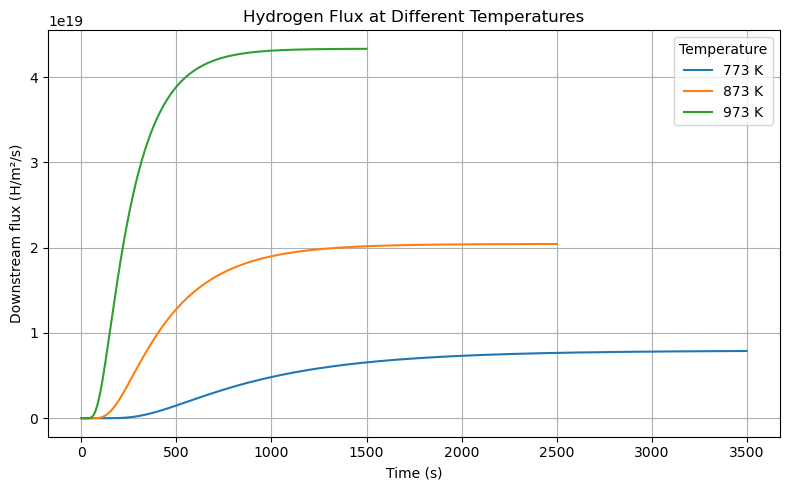

In [1]:
import festim as F
import numpy as np
import matplotlib.pyplot as plt

# Define temperature cases: (temperature in K, final_time in s)
cases = [
    (773, 3500),   # 500°C
    (873, 2500),   # 600°C
    (973, 1500),   # 700°C
]

# Store results for plotting
flux_results = []
time_results = []
labels = []

for temperature_K, final_time in cases:
    print(f"Running simulation for T = {temperature_K} K")

    # Set up simulation
    my_model = F.Simulation()
    my_model.T = temperature_K

    # Mesh
    my_model.mesh = F.MeshFromVertices(
        vertices=np.linspace(0, 2.032e-3, num=200)
    )

    # Material
    my_model.materials = F.Material(id=1, D_0=3.72e-7, E_D=0.42)

    # Boundary conditions
    P_up = 110000  # Pa
    my_model.boundary_conditions = [
        F.SievertsBC(surfaces=1, S_0=5.04e23, E_S=0.13, pressure=P_up),
        F.DirichletBC(surfaces=2, value=0, field=0)
    ]

    # Settings
    my_model.settings = F.Settings(
        absolute_tolerance=1e-2,
        relative_tolerance=1e-8,
        final_time=final_time
    )

    # Time stepping
    my_model.dt = F.Stepsize(initial_value=0.1)

    # Derived quantities
    derived_quantities = F.DerivedQuantities(
        [F.HydrogenFlux(surface=2)],
        show_units=True
    )

    # Exports
    my_model.exports = [derived_quantities]

    # Run
    my_model.initialise()
    my_model.run()

    # Store data
    times = derived_quantities.t
    flux = np.abs(derived_quantities.filter(surfaces=2).data)

    flux_results.append(flux)
    time_results.append(times)
    labels.append(f"{temperature_K} K")  # Label in Kelvin

# Plotting all results
plt.figure(figsize=(8, 5))
for times, flux, label in zip(time_results, flux_results, labels):
    plt.plot(times, flux, label=label)

plt.xlabel("Time (s)")
plt.ylabel("Downstream flux (H/m²/s)")
plt.title("Hydrogen Flux at Different Temperatures")
plt.legend(title="Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()
